# Treinamento e Avaliação com XGBoost
Este notebook treina um modelo XGBoost para prever `preco_medio_ton_usd` e avalia o desempenho usando MSE, RMSE e R².


=== Tipo de carne: bovino ===
Fold 1: MSE=0.1501, RMSE=0.3874, R²=-0.3808
Fold 2: MSE=1.3024, RMSE=1.1412, R²=-1.3453
CV média (treino): MSE=0.7262, RMSE=0.7643, R²=-0.8631
Test MSE: 0.4321
Test RMSE: 0.6574
Test R²: -11.7991


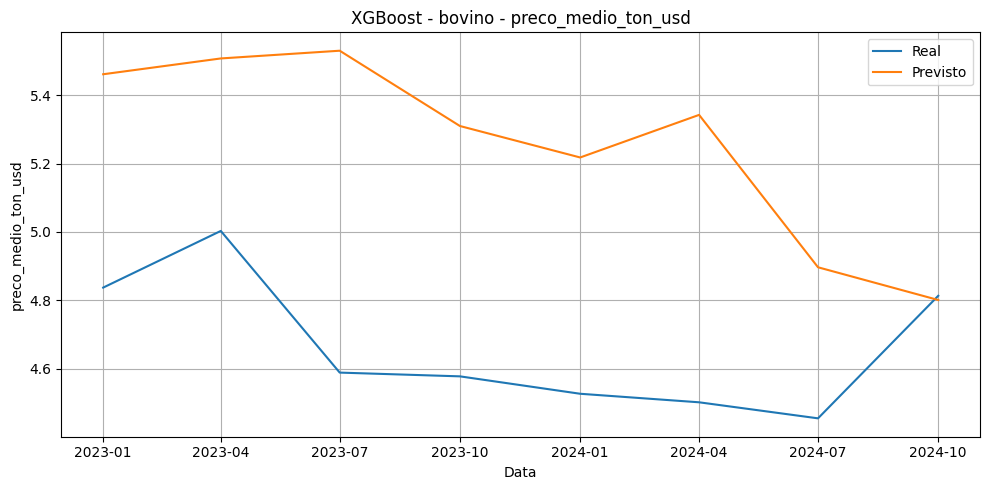


=== Tipo de carne: suino ===
Fold 1: MSE=0.0791, RMSE=0.2813, R²=-0.5965
Fold 2: MSE=0.0555, RMSE=0.2356, R²=-2.5328
CV média (treino): MSE=0.0673, RMSE=0.2584, R²=-1.5646
Test MSE: 0.0083
Test RMSE: 0.0911
Test R²: 0.3354


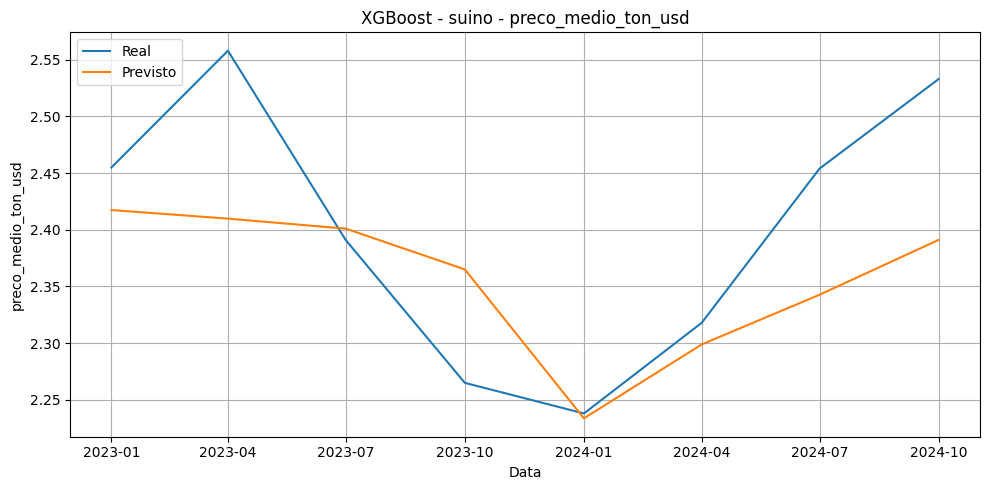


=== Tipo de carne: frango ===
Fold 1: MSE=0.0050, RMSE=0.0710, R²=0.1550
Fold 2: MSE=0.1018, RMSE=0.3191, R²=-0.4015
CV média (treino): MSE=0.0534, RMSE=0.1951, R²=-0.1232
Test MSE: 0.0096
Test RMSE: 0.0979
Test R²: -0.3535


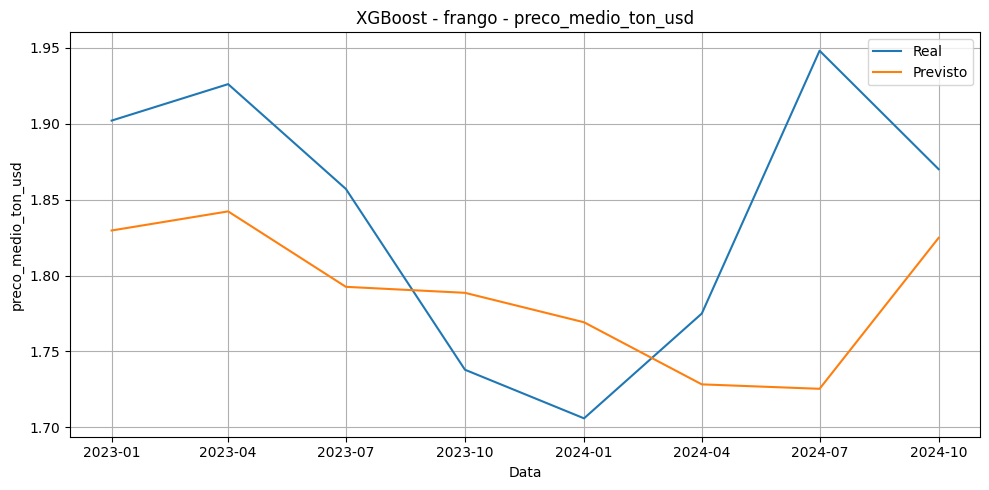


=== Resumo final ===
bovino: train=31, test=8, CV MSE=0.7262, CV RMSE=0.7643, CV R²=-0.8631, Test MSE=0.4321, Test RMSE=0.6574, Test R²=-11.7991
suino: train=31, test=8, CV MSE=0.0673, CV RMSE=0.2584, CV R²=-1.5646, Test MSE=0.0083, Test RMSE=0.0911, Test R²=0.3354
frango: train=31, test=8, CV MSE=0.0534, CV RMSE=0.1951, CV R²=-0.1232, Test MSE=0.0096, Test RMSE=0.0979, Test R²=-0.3535


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Carregar dados
df = pd.read_csv("../carne-brasileira-exportada.csv")
df["date"] = pd.to_datetime(
    df["ano"].astype(str)
    + "-"
    + ((df["trimestre"] - 1) * 3 + 1).astype(str).str.zfill(2)
    + "-01"
)
df = df.sort_values(["tipo_carne", "date"]).reset_index(drop=True)

# Configurar target e tipos de carne
target_column = "preco_medio_ton_usd"  # altere para "exportacao_usd" se quiser outro alvo
meat_types = ["bovino", "suino", "frango"]

feature_columns = [
    "time_index",
    "quarter_sin",
    "quarter_cos",
    "producao_cabecas_anual_mi",
    "abate_cabecas",
    "peso_carcaca_ton",
    "media_cambio_usdbrl",
    "custo_milho_rs",
    "custo_soja_rs",
    f"{target_column}_lag1",
    f"{target_column}_lag2",
    f"{target_column}_lag4",
    "rolling_mean_4",
    "pct_change_4q",
]

all_results = []
for meat_type in meat_types:
    print(f"\n=== Tipo de carne: {meat_type} ===")
    df_filtered = df[df["tipo_carne"] == meat_type].copy()
    df_filtered = df_filtered.sort_values("date").reset_index(drop=True)

    df_filtered["time_index"] = np.arange(len(df_filtered))
    df_filtered["quarter_sin"] = np.sin(2 * np.pi * (df_filtered["trimestre"] - 1) / 4)
    df_filtered["quarter_cos"] = np.cos(2 * np.pi * (df_filtered["trimestre"] - 1) / 4)

    df_filtered[f"{target_column}_lag1"] = df_filtered[target_column].shift(1)
    df_filtered[f"{target_column}_lag2"] = df_filtered[target_column].shift(2)
    df_filtered[f"{target_column}_lag4"] = df_filtered[target_column].shift(4)

    df_filtered["rolling_mean_4"] = df_filtered[target_column].shift(1).rolling(window=4, min_periods=1).mean()
    df_filtered["pct_change_4q"] = df_filtered[target_column].shift(1).pct_change(periods=4)

    df_model = df_filtered.dropna(subset=feature_columns + [target_column]).reset_index(drop=True)
    train_size = int(len(df_model) * 0.8)
    train = df_model.iloc[:train_size]
    test = df_model.iloc[train_size:]

    X_train = train[feature_columns]
    y_train = train[target_column]
    X_test = test[feature_columns]
    y_test = test[target_column]

    tscv = TimeSeriesSplit(n_splits=2)
    val_scores = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]

        fold_model = XGBRegressor(n_estimators=200, random_state=42, objective="reg:squarederror")
        fold_model.fit(X_fold_train, y_fold_train)

        fold_pred = fold_model.predict(X_fold_val)
        fold_mse = mean_squared_error(y_fold_val, fold_pred)
        fold_rmse = np.sqrt(fold_mse)
        fold_r2 = r2_score(y_fold_val, fold_pred)
        val_scores.append((fold_mse, fold_rmse, fold_r2))

        print(f"Fold {fold}: MSE={fold_mse:.4f}, RMSE={fold_rmse:.4f}, R²={fold_r2:.4f}")

    cv_mse = np.mean([score[0] for score in val_scores])
    cv_rmse = np.mean([score[1] for score in val_scores])
    cv_r2 = np.mean([score[2] for score in val_scores])
    print(f"CV média (treino): MSE={cv_mse:.4f}, RMSE={cv_rmse:.4f}, R²={cv_r2:.4f}")

    model = XGBRegressor(
                n_estimators=50,
                max_depth=2,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_lambda=1.0,
                reg_alpha=0.5,
                random_state=42
            )           
    
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f"Test MSE: {mse:.4f}")
    print(f"Test RMSE: {rmse:.4f}")
    print(f"Test R²: {r2:.4f}")

    all_results.append({
        "meat_type": meat_type,
        "cv_mse": cv_mse,
        "cv_rmse": cv_rmse,
        "cv_r2": cv_r2,
        "test_mse": mse,
        "test_rmse": rmse,
        "test_r2": r2,
        "train_size": len(X_train),
        "test_size": len(X_test),
    })

    plt.figure(figsize=(10, 5))
    plt.plot(test["date"].reset_index(drop=True), y_test.values, label="Real")
    plt.plot(test["date"].reset_index(drop=True), predictions, label="Previsto")
    plt.title(f"XGBoost - {meat_type} - {target_column}")
    plt.xlabel("Data")
    plt.ylabel(target_column)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n=== Resumo final ===")
for res in all_results:
    print(
        f"{res['meat_type']}: train={res['train_size']}, test={res['test_size']}, "
        f"CV MSE={res['cv_mse']:.4f}, CV RMSE={res['cv_rmse']:.4f}, CV R²={res['cv_r2']:.4f}, "
        f"Test MSE={res['test_mse']:.4f}, Test RMSE={res['test_rmse']:.4f}, Test R²={res['test_r2']:.4f}"
    )
